#### Download library

In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 787.9 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.0 MB/s eta 0:00:0000:0100:01


#### Seed, Plot, Multi-seed

In [2]:
import os
import random
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch_geometric.utils import to_undirected

from torch_geometric.nn import SAGEConv

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    average_precision_score, confusion_matrix, classification_report
)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def plot_learning_curves(history: dict, model_name: str = "Model") -> None:
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    ax.plot(epochs, history['train_loss'], label='Train Loss')
    ax.plot(epochs, history['val_loss'], label='Val Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{model_name} – Loss')
    ax.legend()
    ax.grid(True)

    ax = axes[1]
    ax.plot(epochs, history['train_f1'], label='Train F1 (illicit)')
    ax.plot(epochs, history['val_f1'], label='Val F1 (illicit)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1-score')
    ax.set_title(f'{model_name} – F1 (illicit)')
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

def run_multiseed(run_single_seed_fn, exp_name="Experiment", seeds=[42, 0, 123]):
    results = []
    for seed in seeds:
        print(f"\n{exp_name} - Seed: {seed}")
        metrics = run_single_seed_fn(seed)
        metrics['seed'] = seed
        results.append(metrics)
        
    print(f"\n {exp_name} multi-seed results")
    metric_keys = [k for k in results[0].keys() if k != 'seed']
    
    for key in metric_keys:
        values = [res[key] for res in results]
        mean_val = np.mean(values)
        std_val = np.std(values)
        
        display_key = {'f1_ill': 'F1(illicit)', 'precision': 'Precision', 'recall': 'Recall', 'auc_pr': 'AUC-PR'}.get(key, key.capitalize())
        print(f"{display_key:<11}: {mean_val:.4f} ± {std_val:.4f}")
        
    return results


#### Data-processing and Architecture

In [3]:
def load_and_preprocess_data(data_path: str, device: torch.device | None = None, undirected: bool = True) -> tuple:
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    data = torch.load(data_path, weights_only=False)
    
    if undirected:
        data.edge_index = to_undirected(data.edge_index)

    train_features = data.x[data.train_mask]
    train_mean = train_features.mean(dim=0)
    train_std = train_features.std(dim=0)
    data.x = (data.x - train_mean) / (train_std + 1e-8)
    print(data)

    data = data.to(device)
    return data, device

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, aggregator_type='max', dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr=aggregator_type)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels, aggr=aggregator_type)
        self.conv3 = SAGEConv(hidden_channels, out_channels, aggr=aggregator_type)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv3(x, edge_index)
        return x

#### Training & Evaluation Logic

In [4]:
class FocalLoss(torch.nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.weight = weight 
        self.gamma = gamma   
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean': return focal_loss.mean()
        elif self.reduction == 'sum': return focal_loss.sum()
        else: return focal_loss

def compute_class_weights(data, device: torch.device, multiplier: float = 2.0) -> torch.Tensor:
    n_licit = (data.y[data.train_mask] == 0).sum().item()
    n_illicit = (data.y[data.train_mask] == 1).sum().item()
    
    illicit_weight = math.sqrt(n_licit / n_illicit) * multiplier
    weight = torch.tensor([1.0, illicit_weight], dtype=torch.float).to(device)
    print(f"Class Weights: Licit=1.0, Illicit={illicit_weight:.2f}")
    return weight

def evaluate(model, data, criterion, mask) -> dict:
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[mask].argmax(dim=1)
        probs = F.softmax(out[mask], dim=1)[:, 1]
        y_true, y_pred, y_prob = data.y[mask].cpu().numpy(), pred.cpu().numpy(), probs.cpu().numpy()
        loss = criterion(out[mask], data.y[mask]).item()

    return {
        'loss': loss, 'accuracy': accuracy_score(y_true, y_pred),
        'precision_ill': precision_score(y_true, y_pred, pos_label=1, zero_division=0), 
        'recall_ill': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_ill': f1_score(y_true, y_pred, pos_label=1, zero_division=0), 
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0), 
        'auc_pr': average_precision_score(y_true, y_prob),
    }

def train_one_epoch(model, data, optimizer, criterion, clip_grad_norm=None):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    if clip_grad_norm is not None:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)
    optimizer.step()
    return loss.item()

def train_with_early_stopping(model, data, optimizer, criterion, save_path: str, num_epochs: int = 200, patience: int = 20, monitor_metric: str = 'f1_ill', clip_grad_norm=None, scheduler=None) -> dict:
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_score, epochs_no_improve, best_epoch = 0.0, 0, 0

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, data, optimizer, criterion, clip_grad_norm=clip_grad_norm)
        train_metrics = evaluate(model, data, criterion, data.train_mask)
        val_metrics = evaluate(model, data, criterion, data.val_mask)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_f1'].append(train_metrics['f1_ill'])
        history['val_f1'].append(val_metrics['f1_ill'])

        if scheduler is not None: scheduler.step()

        if val_metrics[monitor_metric] > best_val_score:
            best_val_score, best_epoch, epochs_no_improve = val_metrics[monitor_metric], epoch, 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1

        print(f"Epoch {epoch:03d}: Train Loss={train_loss:.4f}, Val Loss={val_metrics['loss']:.4f}, Train F1={train_metrics['f1_ill']:.4f}, Val F1={val_metrics['f1_ill']:.4f}, Gap={train_metrics['f1_ill'] - val_metrics['f1_ill']:.4f}")

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (Best epoch: {best_epoch})")
            break
    return history

def print_test_evaluation(model, data, criterion, label: str = "Test") -> None:
    test_metrics = evaluate(model, data, criterion, data.test_mask)
    print(f"{label}\n  Loss          : {test_metrics['loss']:.4f}\n  Accuracy      : {test_metrics['accuracy']:.4f}\n  Precision(ill): {test_metrics['precision_ill']:.4f}\n  Recall(ill)   : {test_metrics['recall_ill']:.4f}\n  F1(illicit)   : {test_metrics['f1_ill']:.4f}\n  F1(macro)     : {test_metrics['f1_macro']:.4f}\n  AUC-PR        : {test_metrics['auc_pr']:.4f}")

    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[data.test_mask].argmax(dim=1)
        y_true, y_pred = data.y[data.test_mask].cpu().numpy(), pred.cpu().numpy()

    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Licit (0)', 'Illicit (1)'], digits=4, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

#### Main execution

Device: cuda
Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
Start training GraphSAGE on Kaggle

GraphSAGE - Seed: 42
GraphSAGE Train - Seed: 42
Class Weights: Licit=1.0, Illicit=5.53


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 001: Train Loss=1.0312, Val Loss=8.2860, Train F1=0.1715, Val F1=0.1505, Gap=0.0210
Epoch 002: Train Loss=0.9260, Val Loss=6.5132, Train F1=0.1994, Val F1=0.1448, Gap=0.0546


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 003: Train Loss=0.7830, Val Loss=4.7256, Train F1=0.2254, Val F1=0.1606, Gap=0.0649
Epoch 004: Train Loss=0.7825, Val Loss=2.7521, Train F1=0.2656, Val F1=0.1791, Gap=0.0864


...

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 181: Train Loss=0.0388, Val Loss=2.3639, Train F1=0.9618, Val F1=0.8140, Gap=0.1478
Epoch 182: Train Loss=0.0413, Val Loss=2.3067, Train F1=0.9548, Val F1=0.7958, Gap=0.1590


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 183: Train Loss=0.0380, Val Loss=2.2651, Train F1=0.9478, Val F1=0.7912, Gap=0.1566
Epoch 184: Train Loss=0.0391, Val Loss=2.2492, Train F1=0.9515, Val F1=0.7876, Gap=0.1638
Early stopping at epoch 184 (Best epoch: 154)


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


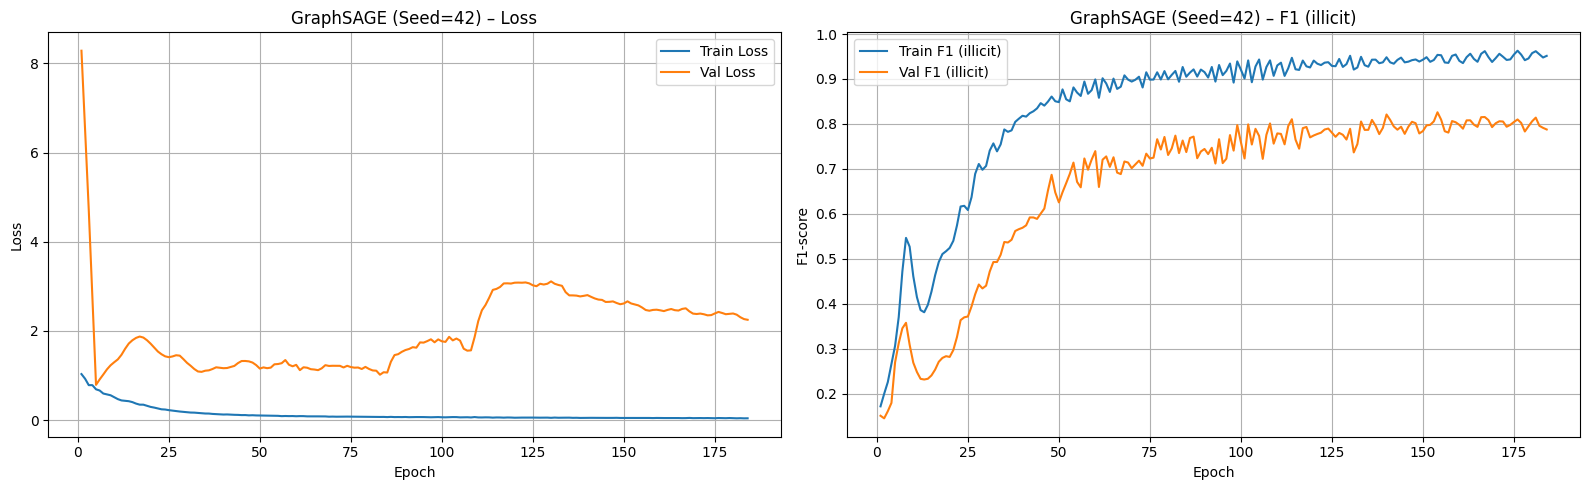

GraphSAGE Test - Seed: 42
  Loss          : 0.7056
  Accuracy      : 0.9586
  Precision(ill): 0.8682
  Recall(ill)   : 0.6734
  F1(illicit)   : 0.7585
  F1(macro)     : 0.8679
  AUC-PR        : 0.7918

Classification Report:
               precision    recall  f1-score   support

   Licit (0)     0.9659    0.9891    0.9774      5132
 Illicit (1)     0.8682    0.6734    0.7585       548

    accuracy                         0.9586      5680
   macro avg     0.9171    0.8312    0.8679      5680
weighted avg     0.9565    0.9586    0.9563      5680

Confusion Matrix:
 [[5076   56]
 [ 179  369]]

GraphSAGE - Seed: 0
GraphSAGE Train - Seed: 0
Class Weights: Licit=1.0, Illicit=5.53
Epoch 001: Train Loss=0.7393, Val Loss=0.9886, Train F1=0.1148, Val F1=0.0441, Gap=0.0707


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 002: Train Loss=0.6461, Val Loss=1.0159, Train F1=0.1531, Val F1=0.0929, Gap=0.0602
Epoch 003: Train Loss=0.6604, Val Loss=1.0540, Train F1=0.2233, Val F1=0.1870, Gap=0.0363


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 004: Train Loss=0.6320, Val Loss=1.0965, Train F1=0.2968, Val F1=0.2557, Gap=0.0411
Epoch 005: Train Loss=0.6029, Val Loss=1.1537, Train F1=0.3656, Val F1=0.2726, Gap=0.0930


...

Epoch 176: Train Loss=0.0384, Val Loss=2.6151, Train F1=0.9510, Val F1=0.7785, Gap=0.1725
Epoch 177: Train Loss=0.0404, Val Loss=2.6313, Train F1=0.9592, Val F1=0.7795, Gap=0.1797


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 178: Train Loss=0.0418, Val Loss=2.5843, Train F1=0.9532, Val F1=0.7650, Gap=0.1882
Epoch 179: Train Loss=0.0381, Val Loss=2.5685, Train F1=0.9507, Val F1=0.7747, Gap=0.1760


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 180: Train Loss=0.0377, Val Loss=2.5875, Train F1=0.9552, Val F1=0.7958, Gap=0.1594
Early stopping at epoch 180 (Best epoch: 150)


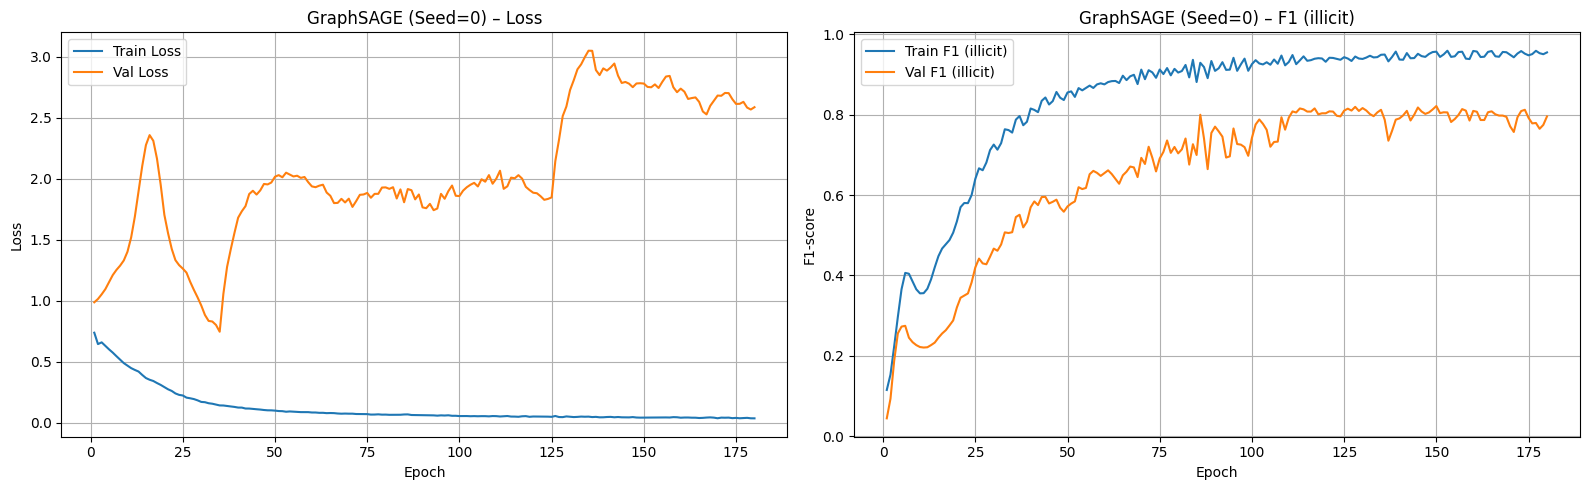

GraphSAGE Test - Seed: 0
  Loss          : 0.7052
  Accuracy      : 0.9563
  Precision(ill): 0.8247
  Recall(ill)   : 0.6953
  F1(illicit)   : 0.7545
  F1(macro)     : 0.8652
  AUC-PR        : 0.7290

Classification Report:
               precision    recall  f1-score   support

   Licit (0)     0.9680    0.9842    0.9760      5132
 Illicit (1)     0.8247    0.6953    0.7545       548

    accuracy                         0.9563      5680
   macro avg     0.8963    0.8397    0.8652      5680
weighted avg     0.9542    0.9563    0.9547      5680

Confusion Matrix:
 [[5051   81]
 [ 167  381]]

GraphSAGE - Seed: 123
GraphSAGE Train - Seed: 123
Class Weights: Licit=1.0, Illicit=5.53
Epoch 001: Train Loss=1.7186, Val Loss=13.9196, Train F1=0.1657, Val F1=0.1436, Gap=0.0221


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 002: Train Loss=1.5279, Val Loss=11.3111, Train F1=0.1700, Val F1=0.1476, Gap=0.0224
Epoch 003: Train Loss=1.3030, Val Loss=8.2244, Train F1=0.1874, Val F1=0.1562, Gap=0.0312


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 004: Train Loss=1.1009, Val Loss=4.3922, Train F1=0.2255, Val F1=0.1704, Gap=0.0551
Epoch 005: Train Loss=1.2108, Val Loss=0.9813, Train F1=0.3012, Val F1=0.2153, Gap=0.0859


...

Epoch 172: Train Loss=0.0459, Val Loss=2.7670, Train F1=0.9526, Val F1=0.7928, Gap=0.1597
Epoch 173: Train Loss=0.0440, Val Loss=2.8600, Train F1=0.9418, Val F1=0.7753, Gap=0.1664


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 174: Train Loss=0.0453, Val Loss=2.9513, Train F1=0.9485, Val F1=0.7835, Gap=0.1650
Epoch 175: Train Loss=0.0439, Val Loss=3.0447, Train F1=0.9615, Val F1=0.7979, Gap=0.1636


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 176: Train Loss=0.0449, Val Loss=3.0426, Train F1=0.9576, Val F1=0.7959, Gap=0.1617
Early stopping at epoch 176 (Best epoch: 146)


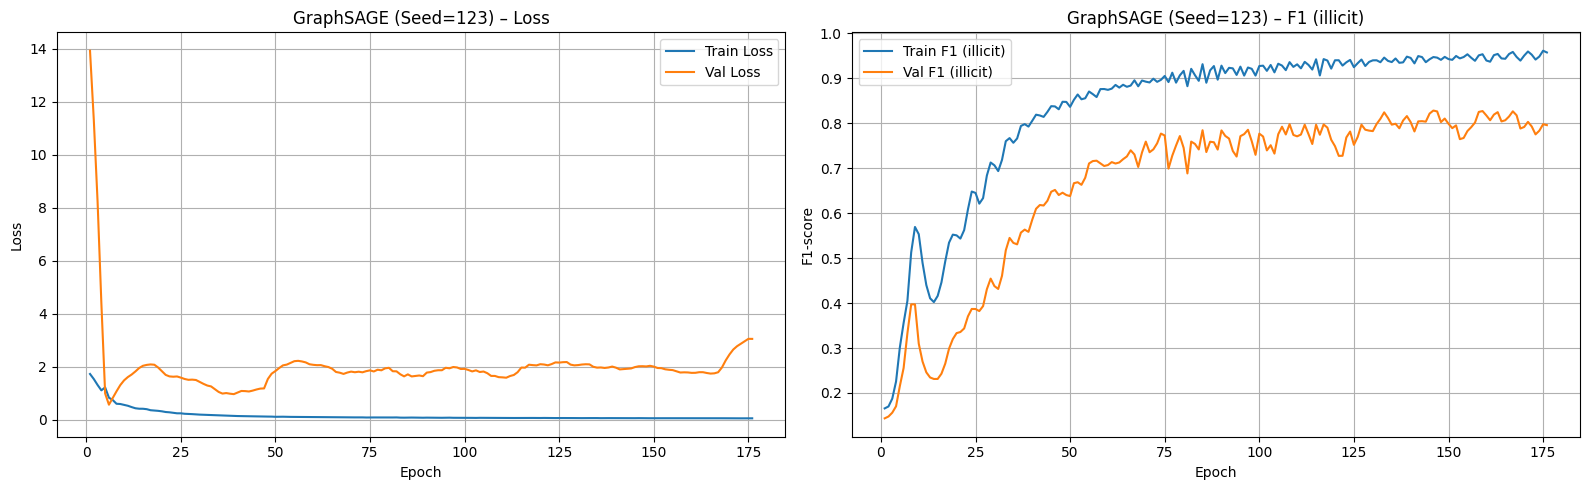

GraphSAGE Test - Seed: 123
  Loss          : 0.6172
  Accuracy      : 0.9546
  Precision(ill): 0.8436
  Recall(ill)   : 0.6496
  F1(illicit)   : 0.7340
  F1(macro)     : 0.8546
  AUC-PR        : 0.7215

Classification Report:
               precision    recall  f1-score   support

   Licit (0)     0.9635    0.9871    0.9752      5132
 Illicit (1)     0.8436    0.6496    0.7340       548

    accuracy                         0.9546      5680
   macro avg     0.9035    0.8184    0.8546      5680
weighted avg     0.9519    0.9546    0.9519      5680

Confusion Matrix:
 [[5066   66]
 [ 192  356]]

 GraphSAGE multi-seed results
Loss       : 0.6760 ± 0.0416
Accuracy   : 0.9565 ± 0.0017
Precision_ill: 0.8455 ± 0.0178
Recall_ill : 0.6727 ± 0.0186
F1(illicit): 0.7490 ± 0.0107
F1_macro   : 0.8626 ± 0.0058
AUC-PR     : 0.7474 ± 0.0315


In [5]:
data_path = '/kaggle/input/datasets/meowll/elliptic-graph-data/elliptic_pyg_data.pt'
data, device = load_and_preprocess_data(data_path, undirected=False)

def run_single_gcn_seed(seed):
    set_seed(seed)
    print(f"GraphSAGE Train - Seed: {seed}")
    
    model = GraphSAGE(
        in_channels=data.x.shape[1],
        hidden_channels=64,
        out_channels=2,
        aggregator_type='max',
        dropout=0.5
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.01, steps_per_epoch=1, epochs=300, pct_start=0.1,
    )
    
    weight = compute_class_weights(data, device, multiplier=2.0)
    criterion = FocalLoss(weight=weight, gamma=2.0)
    
    save_path = f'/kaggle/working/graph_sage_best_seed_{seed}.pt'
    
    history = train_with_early_stopping(
        model, data, optimizer, criterion, scheduler=scheduler,
        save_path=save_path, num_epochs=300, patience=30,
        monitor_metric='f1_ill', clip_grad_norm=1.0
    )
    
    plot_learning_curves(history, model_name=f"GraphSAGE (Seed={seed})")
    
    model.load_state_dict(torch.load(save_path))
    model.eval()
    print_test_evaluation(model, data, criterion, label=f"GraphSAGE Test - Seed: {seed}")
    
    return evaluate(model, data, criterion, data.test_mask)

print("Start training GraphSAGE on Kaggle")
results = run_multiseed(run_single_gcn_seed, "GraphSAGE", seeds=[42, 0, 123])
